# AG-HYPOPT · Trial 13

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twelve trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803; then trial_05 (0.0822), trial_09 (0.0839), trial_11 (0.0859), trial_06 (0.0861), trial_08 (0.0876), trial_12 (0.0882), trial_10 (0.0922). All 0 diverged, gamma finite. Trial_07 sits on a narrow optimum plateau: strong sigma weight (~0.85), kernels near their upper bounds (h_f ~3.9-4.0, h_s ~3.6-3.7) and a gamma cap near ~0.1; changing any of these (cap 0.083/0.15/0.23/0.30, sw 0.50/0.79, sharper kernels) gives a worse objective. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_13'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (12/5 trials)
ID |     ei | params
 1 | 3.2916 | {"gamma_rel_cap": 0.1020562936600401, "h_f_scale": 4.0, "h_s_scale": 3.7992466766727375, "sigma_weight": 0.8444495958702296}
 2 | 3.9321 | {"gamma_rel_cap": 0.2552200840406935, "h_f_scale": 3.98861505962028, "h_s_scale": 1.8935501773878303, "sigma_weight": 0.8433807705338472}
 3 | 3.2144 | {"gamma_rel_cap": 0.14305575366247253, "h_f_scale": 3.1625730850032565, "h_s_scale": 3.6131473521587485, "sigma_weight": 0.8548141598688744}
 4 | 3.8301 | {"gamma_rel_cap": 0.2994888261833856, "h_f_scale": 4.0, "h_s_scale": 2.3133564586876485, "sigma_weight": 0.8457707623734751}
 5 | 2.4517 | {"gamma_rel_cap": 0.18429439579520324, "h_f_scale": 3.9241389267889595, "h_s_scale": 3.8442561977974266, "sigma_weight": 0.8356522003433127}
 6 | 3.4025 | {"gamma_rel_cap": 0.15775641665774423, "h_f_scale": 2.5171745801400407, "h_s_scale": 3.591725615888781, "sigma_weight": 0.8391716868291499}
 7 | 3.7847 | {"gamma_rel_cap": 0.2407973029855824, "h_

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 (0.0803) is the optimum; the batch is again mostly near-copies of it. The single largest objective gain during the campaign came from flattening the kernels (trial_03 -> trial_05), and the flat side of h_s was never taken beyond trial_06's 3.876 (which paired a flat h_s with a low sw).

Candidate 1 (ei 3.2916) holds the near-optimal sw, h_f and small cap (0.844, 4.0, cap 0.102) but pushes h_s a little flatter than trial_07 (3.799 vs 3.675), probing the winning flatness direction with the sigma weight held strong - unlike trial_06, which conflated flat h_s with a weak sigma link. The top-ei draw (id 8) is a near-exact replica of trial_07 and would add little; id 8's only novelty relative to trial_07 is a slightly sharper h_s.

I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # candidate 1: sigma_weight 0.844, h_f_scale 4.0, h_s_scale 3.799, gamma_rel_cap 0.102 (in-region, flatter h_s)


chosen: {'gamma_rel_cap': 0.1020562936600401, 'h_f_scale': 4.0, 'h_s_scale': 3.7992466766727375, 'sigma_weight': 0.8444495958702296}
Running  1nW Trans05 ... 

μ 9.39 -> 6.03 | γ 8.5 -> 4.98 | NLL 0.24


Running  1nW Trans20 ... 

μ 17.32 -> 27.72 | γ 8.5 -> 5.40 | NLL 0.63


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 63.93 | γ 14.1 -> 14.04 | NLL 0.69


Running 3nW Trans100 ... 

μ 175.71 -> 99.04 | γ 14.1 -> 13.71 | NLL 0.67



Total: 7.8 min


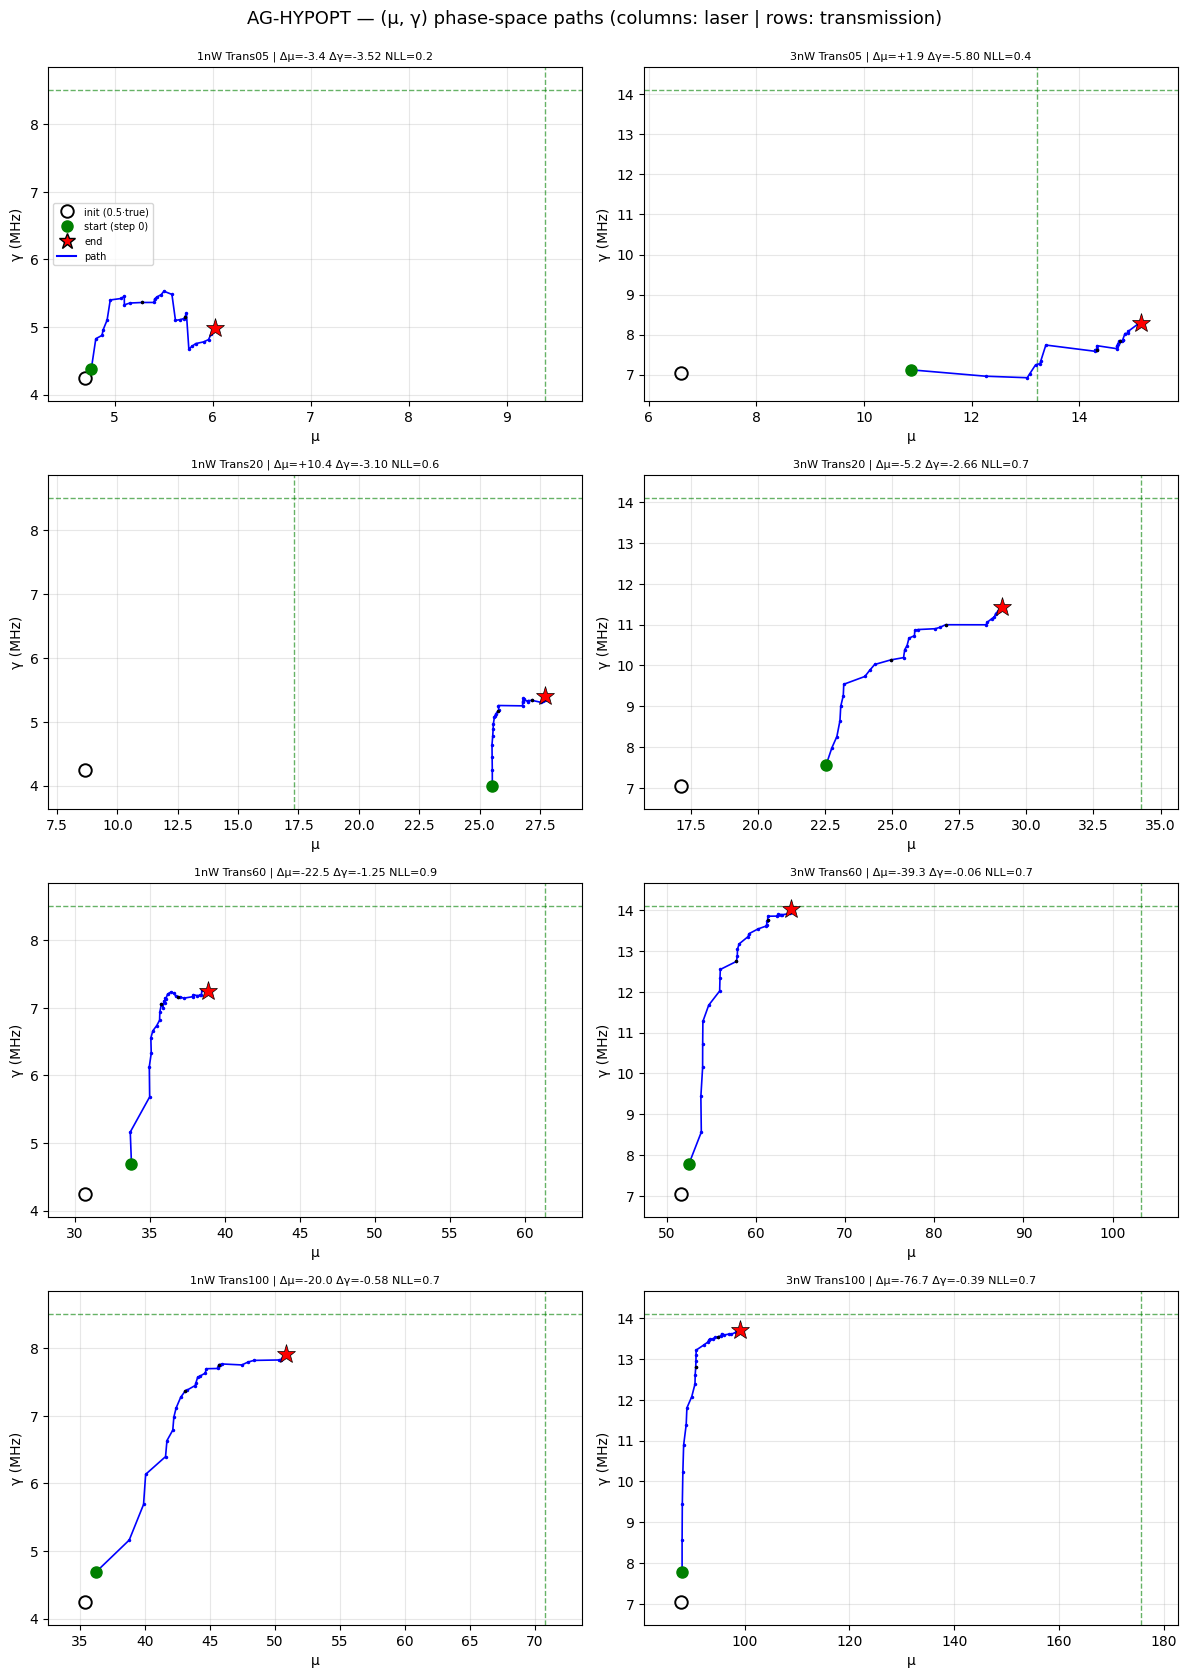

trial finished in 7.8 min
objective = 0.0888 ± 0.0244
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.03   -35.8 |     8.50    4.98   -41.4
1nW Trans20       17.32   27.72   +60.1 |     8.50    5.40   -36.5
1nW Trans60       61.37   38.90   -36.6 |     8.50    7.25   -14.7
1nW Trans100       70.82   50.84   -28.2 |     8.50    7.92    -6.9
3nW Trans05       13.20   15.15   +14.7 |    14.10    8.30   -41.1
3nW Trans20       34.28   29.08   -15.2 |    14.10   11.44   -18.9
3nW Trans60      103.20   63.93   -38.1 |    14.10   14.04    -0.4
3nW Trans100      175.71   99.04   -43.6 |    14.10   13.71    -2.8

weighted objective (T-graded, cap=1.0) = 0.0888 | diverged cells: 0
μ: RMSE 32.547 (rel 36.8%, bias -19.326) | γ: RMSE 2.845 (rel 25.9%, bias -2.171)


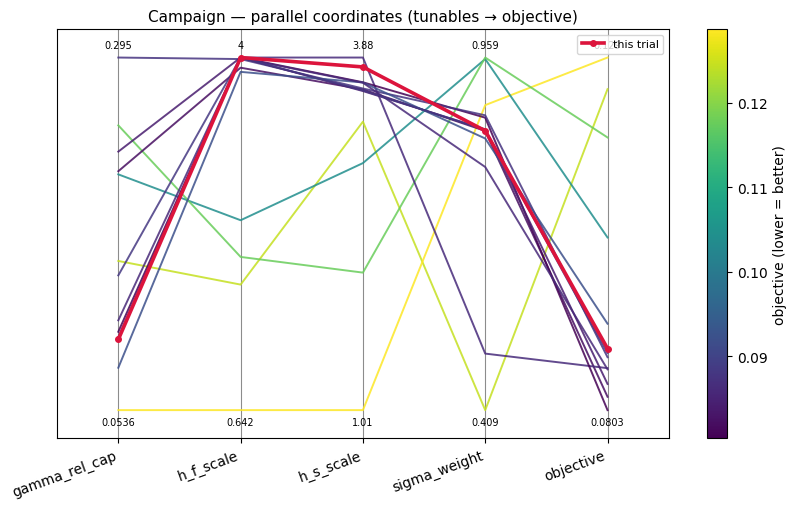

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 13 (sw 0.844, h_f 4.0, h_s 3.799, cap 0.102) ran to completion in 7.8 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0888 +/- 0.0244 - worse than trial_07 (0.0803), near trial_12 (0.0882) and trial_10 (0.0922).

mu rel-RMSE 36.8% (slightly worse than trial_07's 35.9%); same shape - high-T undershoot (3nW Trans100 -43.6%, 3nW Trans60 -38.1%, 1nW Trans60 -36.6%, 1nW Trans100 -28.2%), low-T overshoot (1nW Trans20 +60.1%, 3nW Trans05 +14.7%); bias -19.33.

gamma rel-RMSE 25.9% (worse than trial_07's 22.3%): low T under-estimated (1nW Trans05 -41.4%, 3nW Trans05 -41.1%, 1nW Trans20 -36.5%), high T near truth (-0.4%, -2.8%).

The candidate held the near-optimal sw, h_f and small cap and only flattened h_s to 3.799; the objective did not improve. Together with the sharp-side results (trial_02 h_s 1.01, trial_04 h_s 2.13 much worse), this places the kernel-flatness optimum interior to the sampled range, near h_s ~3.6-3.7 rather than at the boundary.

**Summary:** Trial 13 (sw=0.844, h_f=4.0, h_s=3.799, cap=0.102) finished in 7.8 min with 0 diverged cells and gamma finite, objective 0.0888 +/- 0.0244 - worse than trial_07 (mu rel-RMSE 36.8%, gamma rel-RMSE 25.9%).
**Key insight:** Flattening h_s further (3.675 -> 3.799) did not help, so the kernel-flatness optimum is interior to the sampled range (h_s ~3.6-3.7), not at the boundary.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 13 (sw=0.844, h_f=4.0, h_s=3.799, cap=0.102): objective 0.0888 +/- 0.0244 - worse than trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 36.8%, gamma rel-RMSE 25.9%).'
KEY_INSIGHT = 'Flattening h_s further (3.675 -> 3.799) did not help, so the kernel-flatness optimum is interior to the sampled range (h_s ~3.6-3.7), not at the boundary.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_13 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_14.ipynb. Open it and follow its cells from the top.
